In [32]:
import numpy as np
import sys

In [33]:
old_paths = np.load('old_paths.npy')
shifted_paths = np.load('../test/store/shifted_paths.npy')

In [34]:
old_paths.shape, shifted_paths.shape

((100, 4000, 3), (2025, 4000, 3))

In [35]:
new_shifted_paths = []

In [36]:
# center_pos_x = 2.0*4.4 + 0.6/2+3.8/2
# center_pos_y = 2.0*4.4 + 0.6/2 + 3.8/2
pitch = 4.4
gap = 0.6
size = 3.8
center_pos_x = 2.0*pitch + gap/2 + size/2
center_pos_y = 2.0*pitch + gap/2 + size/2

In [37]:
# for lvl in range(10):
#     for i in range(10):
#         newpath = [[center_pos_x+x[0], center_pos_y+x[1], x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

#     for i in range(10):
#         newpath = [[center_pos_x+x[0], center_pos_y+x[1]+pitch, x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

#     for i in range(5):
#         newpath = [[center_pos_x+x[0], center_pos_y+x[1]+2*pitch, x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

# for lvl in range(10):
#     for i in range(10):
#         newpath = [[center_pos_x+x[0]+pitch, center_pos_y+x[1], x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

#     for i in range(10):
#         newpath = [[center_pos_x+x[0]+pitch, center_pos_y+x[1]+pitch, x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

#     for i in range(5):
#         newpath = [[center_pos_x+x[0]+pitch, center_pos_y+x[1]+2*pitch, x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

# for lvl in range(5):
#     for i in range(10):
#         newpath = [[center_pos_x+x[0]+2*pitch, center_pos_y+x[1], x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

#     for i in range(10):
#         newpath = [[center_pos_x+x[0]+2*pitch, center_pos_y+x[1]+pitch, x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

#     for i in range(5):
#         newpath = [[center_pos_x+x[0]+2*pitch, center_pos_y+x[1]+2*pitch, x[2]] for x in old_paths[i+lvl*10]]
#         new_shifted_paths.append(newpath)

In [38]:
npix = int(9/2) # 4
npaths = 10
for ix_pix in range(npix):
    for lvl in range(npaths):
        for iy_pix in range(npix):
            for i in range(npaths):
                newpath = [[center_pos_x+x[0]+ix_pix*pitch, center_pos_y+x[1]+iy_pix*pitch, x[2]] for x in old_paths[i+lvl*npaths]]
                new_shifted_paths.append(newpath)

        for i in range(5):
            newpath = [[center_pos_x+x[0]+ix_pix*pitch, center_pos_y+x[1]+npix*pitch, x[2]] for x in old_paths[i+lvl*npaths]]
            new_shifted_paths.append(newpath)

for lvl in range(5):
    for iy_pix in range(npix):
        for i in range(npaths):
            newpath = [[center_pos_x+x[0]+npix*pitch, center_pos_y+x[1]+iy_pix*pitch, x[2]] for x in old_paths[i+lvl*npaths]]
            new_shifted_paths.append(newpath)

    for i in range(5):
        newpath = [[center_pos_x+x[0]+npix*pitch, center_pos_y+x[1]+npix*pitch, x[2]] for x in old_paths[i+lvl*npaths]]
        new_shifted_paths.append(newpath)

In [39]:
new_shifted_paths = np.array(new_shifted_paths)
new_shifted_paths.shape

(2025, 4000, 3)

In [40]:
shifted_paths.shape

(2025, 4000, 3)

## Comparison: `new_shifted_paths` vs `shifted_paths`

In [41]:
import matplotlib.pyplot as plt

# --- Shape & basic stats ---
print("=== Shape ===")
print(f"shifted_paths:     {shifted_paths.shape}")
print(f"new_shifted_paths: {new_shifted_paths.shape}")

print("\n=== Value range (x, y, z) ===")
for name, arr in [("shifted_paths", shifted_paths), ("new_shifted_paths", new_shifted_paths)]:
    print(f"\n{name}:")
    for i, ax in enumerate("xyz"):
        print(f"  {ax}: [{arr[:,:,i].min():.4f}, {arr[:,:,i].max():.4f}]")

print("\n=== Mean per axis ===")
for name, arr in [("shifted_paths", shifted_paths), ("new_shifted_paths", new_shifted_paths)]:
    means = arr.mean(axis=(0, 1))
    print(f"  {name}: x={means[0]:.4f}  y={means[1]:.4f}  z={means[2]:.4f}")

=== Shape ===
shifted_paths:     (2025, 4000, 3)
new_shifted_paths: (2025, 4000, 3)

=== Value range (x, y, z) ===

shifted_paths:
  x: [11.2129, 30.5800]
  y: [11.2129, 30.5800]
  z: [9.8332, 148.0000]

new_shifted_paths:
  x: [11.2129, 30.5800]
  y: [11.2129, 30.5800]
  z: [9.8377, 29.6000]

=== Mean per axis ===
  shifted_paths: x=20.8906  y=20.8906  z=39.7869
  new_shifted_paths: x=20.8840  y=20.8840  z=10.3749


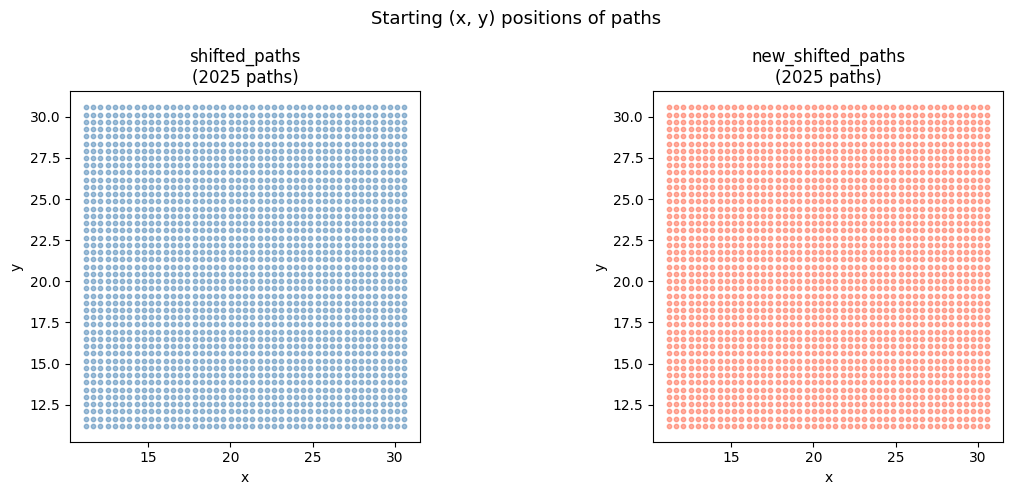

In [42]:
# --- XY scatter of starting points ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, arr, color in zip(
    axes,
    ["shifted_paths", "new_shifted_paths"],
    [shifted_paths, new_shifted_paths],
    ["steelblue", "tomato"],
):
    # use first point of each path as its "origin"
    ax.scatter(arr[:, 0, 0], arr[:, 0, 1], s=10, alpha=0.5, color=color)
    ax.set_title(f"{name}\n({arr.shape[0]} paths)")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_aspect("equal")

plt.suptitle("Starting (x, y) positions of paths", fontsize=13)
plt.tight_layout()
plt.show()

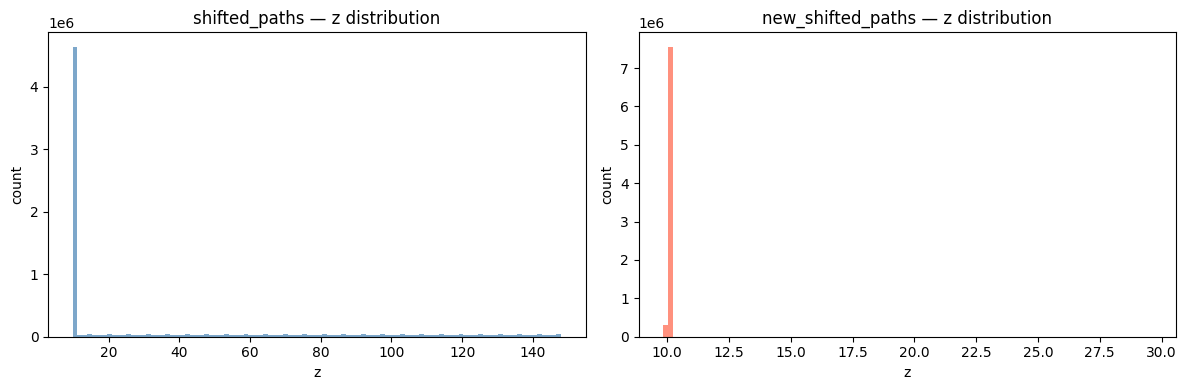

In [43]:
# --- Z (energy/depth) distributions ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, arr, color in zip(
    axes,
    ["shifted_paths", "new_shifted_paths"],
    [shifted_paths, new_shifted_paths],
    ["steelblue", "tomato"],
):
    ax.hist(arr[:, :, 2].ravel(), bins=100, color=color, alpha=0.7)
    ax.set_title(f"{name} — z distribution")
    ax.set_xlabel("z"); ax.set_ylabel("count")

plt.tight_layout()
plt.show()

Unique (x,y) start positions — shifted_paths:     2025
Unique (x,y) start positions — new_shifted_paths: 2025


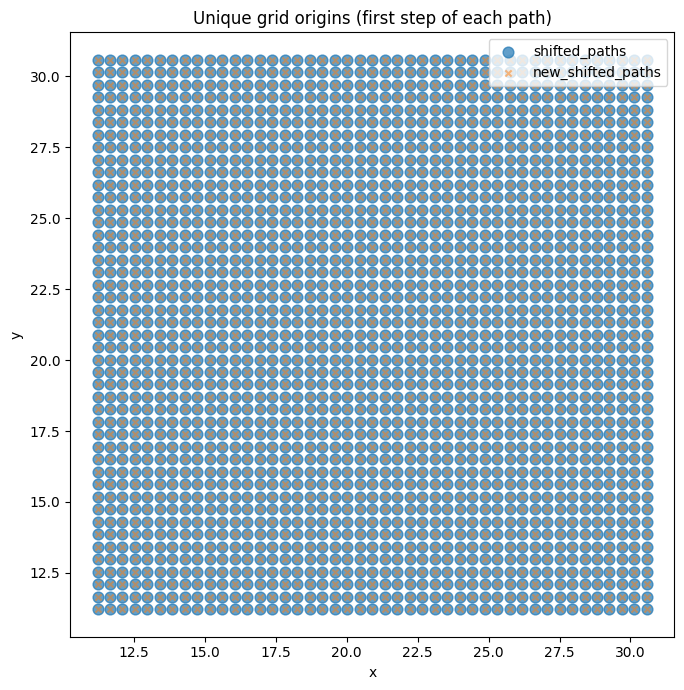

In [44]:
# --- Overlay: unique grid positions (distinct pixel offsets) ---
def unique_starts(arr, decimals=3):
    pts = np.round(arr[:, 0, :2], decimals)
    return np.unique(pts, axis=0)

u_old = unique_starts(shifted_paths)
u_new = unique_starts(new_shifted_paths)

print(f"Unique (x,y) start positions — shifted_paths:     {len(u_old)}")
print(f"Unique (x,y) start positions — new_shifted_paths: {len(u_new)}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(u_old[:, 0], u_old[:, 1], s=60, label="shifted_paths", alpha=0.7, marker="o")
ax.scatter(u_new[:, 0], u_new[:, 1], s=20, label="new_shifted_paths", alpha=0.5, marker="x")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend()
ax.set_title("Unique grid origins (first step of each path)")
plt.tight_layout()
plt.show()